In [1]:
# --- Inputs: set once per recording/sorting run --- M1
raw_data_folder = r"C:\\SGL_DATA\\20260625_exp1_g0\\20260625_exp1_g0_imec0"
sorter_output_path = r"kilosort4_imec_ap_20260625_exp1_g0_job46233787\\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260625_exp1_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [3]:
# --- Inputs: set once per recording/sorting run --- M2
raw_data_folder = r"C:\\SGL_DATA\\20260707_LGN_exp_g0\\20260707_LGN_exp_g0_imec0"
sorter_output_path = r"kilosort4_imec_ap_20260707_LGN_exp_g0_job47328234\\sorter_output"
nidq_file_path = r"C:\\SGL_DATA\\20260707_LGN_exp_g0"  # folder containing the .nidq.bin/.meta (BNC channels)

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import spikeinterface.extractors as se
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# select all the LGN units (label "good") for downstream analysis
# unit_data = pickle.load(open("kilosort4_imec_ap_20260707_LGN_exp_job47328234\\unit_spike_data.pkl", "rb"))
unit_data = pickle.load(open("kilosort4_imec_ap_20260625_exp1_job46233787\\unit_spike_data.pkl", "rb"))
lgn_channel_range = range(10,50) # inclusive LGN channel range # (10,50) for M1, (0,55) for M2
lgn_units = [
    unit_id
    for unit_id, record in unit_data.items()
    if record["quality_label"] == "good" and record["channel"] in lgn_channel_range
]
# unwanted_units = [22, 48]
# lgn_units = [unit_id for unit_id in lgn_units if unit_id not in unwanted_units]
# lgn_units = [27, 30, 31, 32, 33]
lgn_units = [unit_id for unit_id in lgn_units if unit_data[unit_id]["spike_times_s"].size < 100000]  # filter out units with too many spikes
# < 100000 for M1, < 200000 for M2

lgn_spike_times = {
    unit_id: unit_data[unit_id]["spike_times_s"]
    for unit_id in lgn_units
}
print(f"Selected {len(lgn_units)} good LGN units for downstream analysis")

# bnc processing functions
def _load_bnc_window(nidq_recording, nidq_fs, bnc_channel_id, t0, t1):
    start_frame = max(0, int(t0 * nidq_fs))
    end_frame = min(nidq_recording.get_num_samples(), int(t1 * nidq_fs))
    trace = nidq_recording.get_traces(
        channel_ids=[bnc_channel_id], start_frame=start_frame, end_frame=end_frame
    ).flatten()
    time = np.arange(start_frame, end_frame) / nidq_fs
    return time, trace

def _detect_chirp_onsets(time, trace, threshold, min_isi_s):
    thr = threshold if threshold is not None else (trace.max().astype(float) + trace.min()) / 2
    above = trace > thr
    rising_edges = np.flatnonzero(~above[:-1] & above[1:]) + 1
    onsets = time[rising_edges]
    if onsets.size:
        keep = np.diff(onsets, prepend=-np.inf) > min_isi_s
        onsets = onsets[keep]
    return onsets

Selected 28 good LGN units for downstream analysis


In [ ]:
# curate per-cell, per-trial firing rate traces for classifier training (no pooling across units, no averaging across trials)
cycle_start = np.array([[0, 48, 67], [7, 30, 76], [16, 39, 60]])  # nominal start times of each trial (search window; refined via chirp detection)
# [0, 48, 67] for 12hz
# [7, 30, 76] for 4+12hz
# [16, 39, 60] for 18+ 12hz
start_time = 2971.0     #1893.0  # 2971.0  # 1921.0

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

trial_period_s = 90       # nominal spacing between trials
lapse_s = 8               # window length per trial, from each trial's aligned start
n_trials = 10                # number of trials per condition
bin_size_s = 0.01            # firing-rate bin width (s)
smooth_bins = 4              # moving-average window, in bins

bin_edges = np.arange(0, lapse_s + bin_size_s, bin_size_s)
n_bins = bin_edges.size - 1

show_bnc = bool(nidq_file_path)
if show_bnc:
    nidq_recording = se.read_spikeglx(folder_path=nidq_file_path, stream_id="nidq")
    nidq_fs = nidq_recording.get_sampling_frequency()
    bnc_channel_id = nidq_recording.channel_ids[0]

# each row of cycle_start is its own stimulus condition (row 1 = "4-12", row 2 = "18-12"),
# so each is thresholded and start-time-adjusted independently rather than sharing one
# vectorized chirp search - _load_bnc_window only accepts a scalar start time
condition_rows = {"4-12": 1, "18-12": 2}
firing_rates = {}  # condition label -> array (n_trials, n_units, n_bins)

for label, cycle_row in condition_rows.items():
    first_trial_start_s = start_time + cycle_start[cycle_row]
    trial_start_times = np.array([first_trial_start_s + i * trial_period_s for i in range(n_trials)]).flatten()

    trial_unit_rates = np.zeros((len(trial_start_times), n_units, n_bins))
    for k in range(len(trial_start_times)):
        nominal_start = trial_start_times[k]
        trial_start = nominal_start
        if show_bnc:
            # re-center each trial on its actual chirp onset, same logic as plot_raster,
            # since the ~90s cadence isn't perfectly accurate
            search_time, search_trace = _load_bnc_window(
                nidq_recording, nidq_fs, bnc_channel_id, nominal_start, nominal_start + lapse_s
            )
            onsets = _detect_chirp_onsets(search_time, search_trace, None, 30.0)
            if onsets.size:
                trial_start = onsets[0]
        trial_end = trial_start + lapse_s

        for u, unit_id in enumerate(unit_ids):
            times = lgn_spike_times[unit_id]
            window_spikes = times[(times >= trial_start) & (times < trial_end)] - trial_start
            counts, _ = np.histogram(window_spikes, bins=bin_edges)
            rate = counts / bin_size_s
            trial_unit_rates[k, u] = np.convolve(rate, np.ones(smooth_bins) / smooth_bins, mode="same")

    firing_rates[label] = trial_unit_rates
    print(f"{label}: firing rate array shape {trial_unit_rates.shape} (trials, units, time bins)")

firing_rate_4_12 = firing_rates["4-12"][:, :,200:400]
firing_rate_18_12 = firing_rates["18-12"][:, :,200:400]
print(f"firing_rate_4_12 shape: {firing_rate_4_12.shape}, firing_rate_18_12 shape: {firing_rate_18_12.shape}")

4-12: firing rate array shape (30, 28, 800) (trials, units, time bins)
18-12: firing rate array shape (30, 28, 800) (trials, units, time bins)
firing_rate_4_12 shape: (30, 28, 50), firing_rate_18_12 shape: (30, 28, 50)


In [6]:
def compute_power(FR_matrix, frq_range):
    # compute power of firing rate matrix in a given frequency range
    bin_size_s = 0.01
    unit_num = FR_matrix.shape[1]
    trial_num = FR_matrix.shape[0]

    freqs = np.fft.rfftfreq(FR_matrix.shape[2], d=bin_size_s)
    freq_mask = freqs > 2
    freqs = freqs[freq_mask]

    powers = np.zeros((trial_num, unit_num), dtype=float)
    power_spectra = np.zeros((trial_num, unit_num, len(freqs)), dtype=float)
    for trial in range(trial_num):
        for unit_idx in range(unit_num):
            signal = FR_matrix[trial, unit_idx] - FR_matrix[trial, unit_idx].mean()
            power = np.abs(np.fft.rfft(signal)) ** 2
            power = power[freq_mask]
            power_interest = power[(freqs >= frq_range[0]) & (freqs <= frq_range[1])].sum()
            powers[trial, unit_idx] = power_interest
            power_spectra[(trial, unit_idx)] = power

    return powers, power_spectra, freqs


0


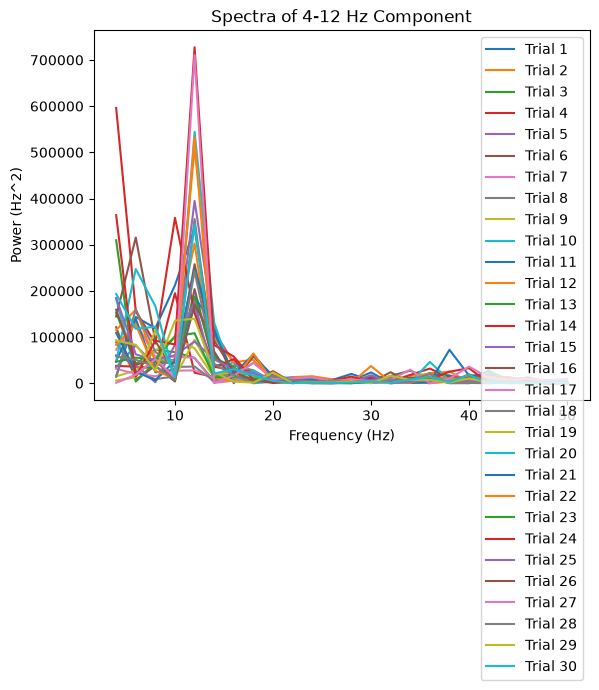

In [7]:
power_4_12_test, power_4_12_spectra, freqs = compute_power(firing_rate_4_12, (11, 13))
unit_ids = list(lgn_spike_times.keys())
idx = 0
print(unit_ids[idx])
for trial in range(firing_rate_4_12.shape[0]):
    plt.plot(freqs, power_4_12_spectra[trial, idx], label=f"Trial {trial+1}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Hz^2)")
plt.title("Spectra of 4-12 Hz Component")
plt.legend()
plt.show()

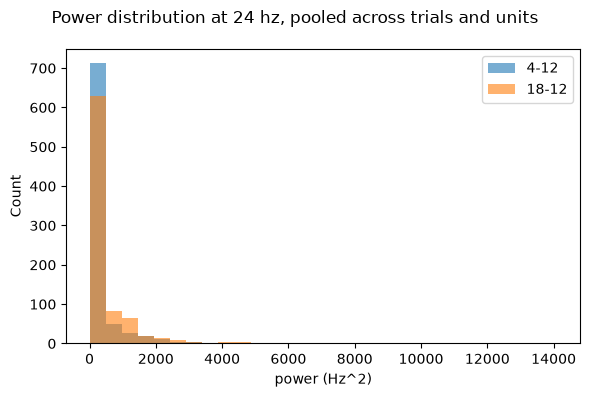

151.77869247799427


In [19]:
# plot histograms of 4-12 vs 18-12 power distributions at 24 hz
from scipy.stats import wasserstein_distance
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]
power_4_12, _, _ = compute_power(firing_rate_4_12, (23, 25))
power_18_12, _, _ = compute_power(firing_rate_18_12, (23, 25))
power_4_12_flat = power_4_12.flatten()
power_18_12_flat = power_18_12.flatten()

fig, ax = plt.subplots(figsize=(6, 4))
power = np.concatenate([power_4_12_flat, power_18_12_flat])
bins = np.linspace(power.min(), power.max(), 30)
ax.hist(power_4_12_flat, bins=bins, color="tab:blue", alpha=0.6, label=stim_hz[3])
ax.hist(power_18_12_flat, bins=bins, color="tab:orange", alpha=0.6, label=stim_hz[5])
ax.set_xlabel("power (Hz^2)")
ax.set_ylabel("Count")
ax.legend()

fig.suptitle("Power distribution at 24 hz, pooled across trials and units")
plt.tight_layout()
plt.show()

emd = wasserstein_distance(power_4_12_flat, power_18_12_flat)
print(emd)

[4, 5, 10, 11, 15, 24]


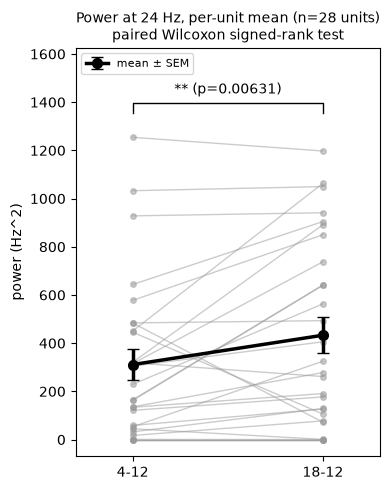

Wilcoxon signed-rank statistic=61.000, p=0.006313


In [23]:
# --- Paired line plot: per-unit mean power at 24 hz, 4-12 vs 18-12, with paired significance test ---
from scipy.stats import wilcoxon

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

# per-unit mean power across trials (power_4_12 / power_18_12 are (n_trials, n_units), from the pooled-histogram cell above)
unit_power_4_12 = power_4_12.mean(axis=0)
unit_power_18_12 = power_18_12.mean(axis=0)

fig, ax = plt.subplots(figsize=(4, 5))
x = [0, 1]

anti_list = []
for i in range(n_units):
    if unit_power_4_12[i] > unit_power_18_12[i]:
        anti_list.append(i)
    ax.plot(x, [unit_power_4_12[i], unit_power_18_12[i]],
             color="#999999", alpha=0.5, linewidth=1, marker="o", markersize=4, zorder=2)
print(anti_list)

mean_vals = [unit_power_4_12.mean(), unit_power_18_12.mean()]
sem_vals = [unit_power_4_12.std(ddof=1) / np.sqrt(n_units), unit_power_18_12.std(ddof=1) / np.sqrt(n_units)]
ax.errorbar(x, mean_vals, yerr=sem_vals, color="black", linewidth=2.5,
            marker="o", markersize=7, capsize=4, zorder=3, label="mean ± SEM")

ax.set_xticks(x)
ax.set_xticklabels([stim_hz[3], stim_hz[5]])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("power (Hz^2)")
ax.legend(fontsize=8, loc="upper left")

# paired significance test (Wilcoxon signed-rank, matched by unit)
stat, p_value = wilcoxon(unit_power_4_12, unit_power_18_12)
if p_value < 0.001:
    sig_label = "***"
elif p_value < 0.01:
    sig_label = "**"
elif p_value < 0.05:
    sig_label = "*"
else:
    sig_label = "ns"

y_top = max(unit_power_4_12.max(), unit_power_18_12.max())
y_bracket = y_top * 1.08
ax.plot([0, 0, 1, 1], [y_bracket, y_bracket * 1.03, y_bracket * 1.03, y_bracket], color="black", linewidth=1, zorder=3)
ax.text(0.5, y_bracket * 1.05, f"{sig_label} (p={p_value:.3g})", ha="center", va="bottom", fontsize=10)
ax.set_ylim(top=y_bracket * 1.2)

ax.set_title(f"Power at 24 Hz, per-unit mean (n={n_units} units)\npaired Wilcoxon signed-rank test", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Wilcoxon signed-rank statistic={stat:.3f}, p={p_value:.4g}")

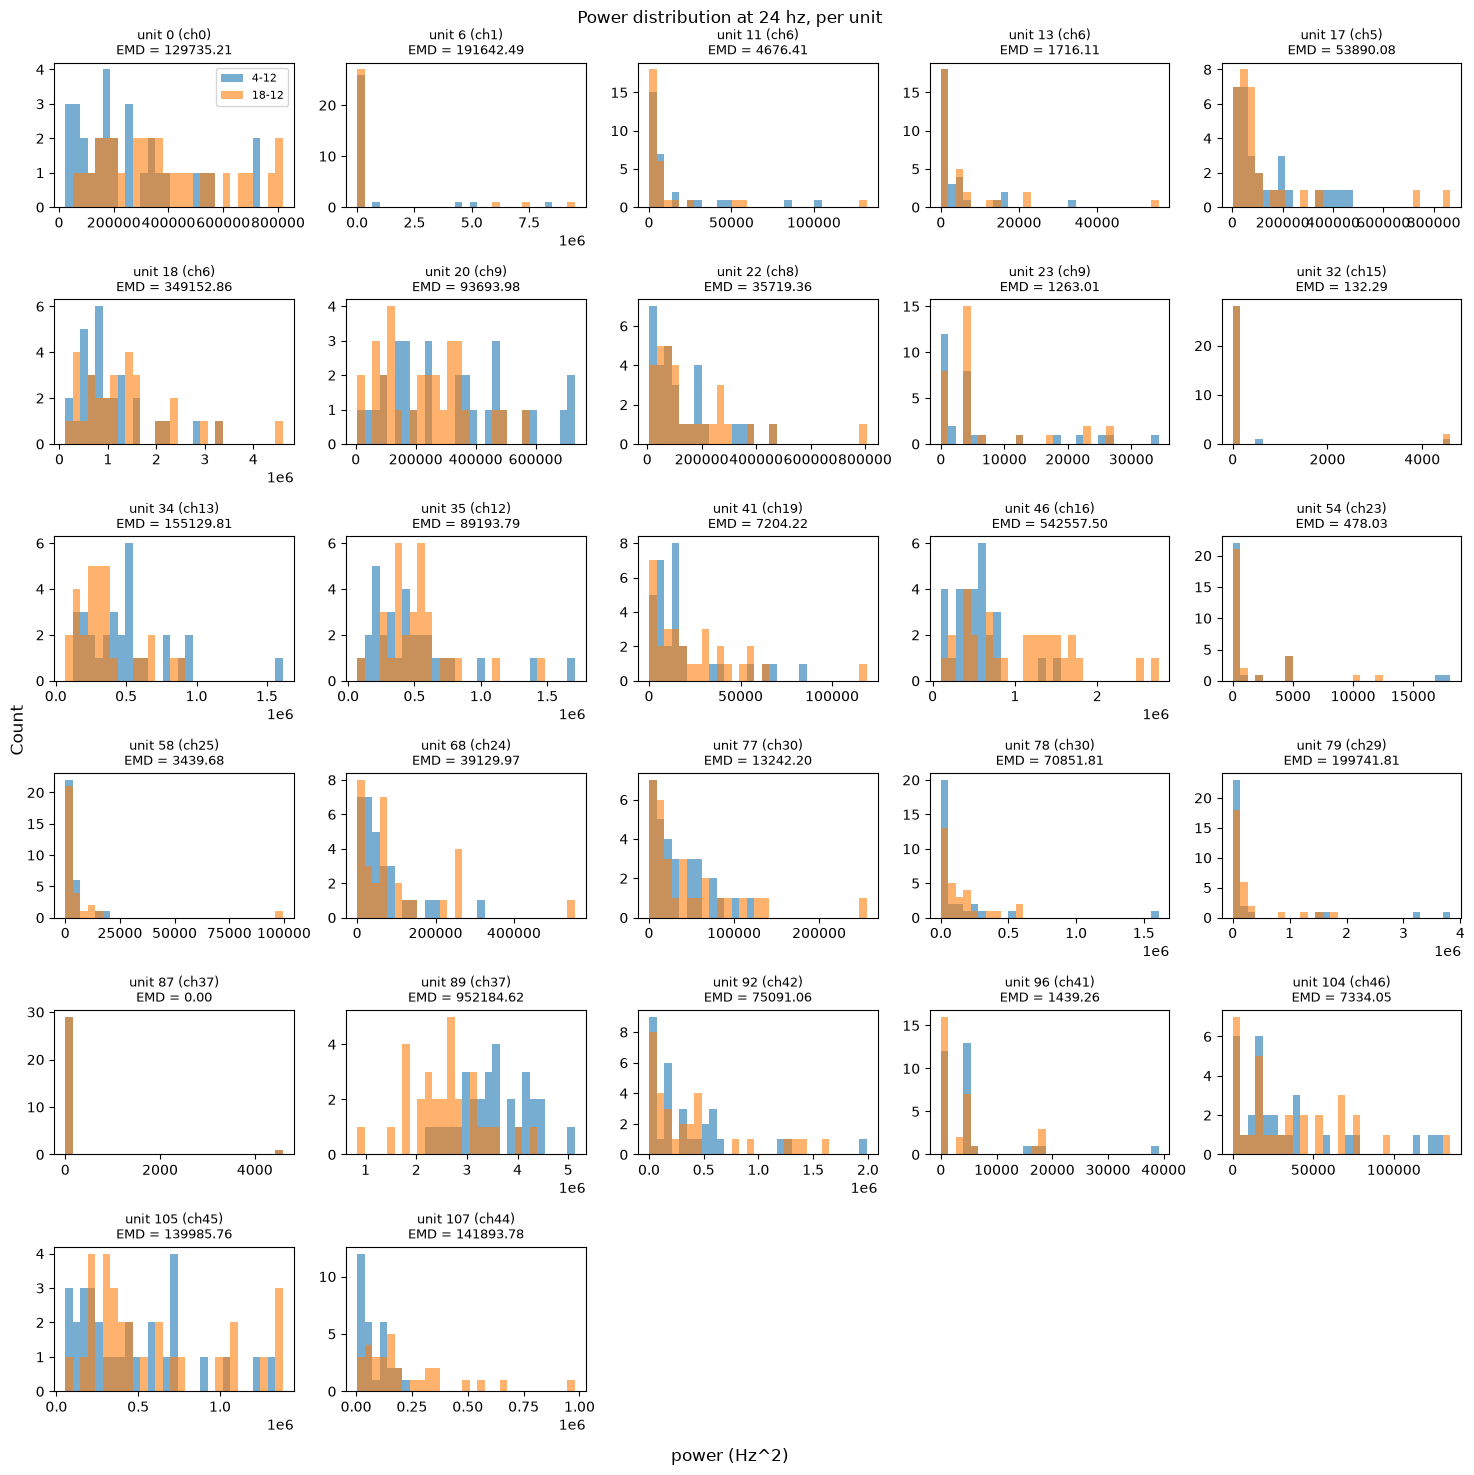

In [10]:
# --- Per-unit histogram of peak-to-trough amplitude, one subplot per unit, overlaying
# both stimulus conditions in different colors, labeled with the Earth Mover's Distance
# (Wasserstein distance) between each unit's 4-12 and 18-12 trial-power distributions ---
from scipy.stats import wasserstein_distance

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)
stim_hz = ["12", "NA", "4", "4-12", "18", "18-12"]

ncols = 5
nrows = int(np.ceil(n_units / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = axes[i // ncols][i % ncols]
    # power_4_12/power_18_12 are (n_trials, n_units) - select unit i across all trials
    unit_power_4_12 = power_4_12[:, i]
    unit_power_18_12 = power_18_12[:, i]

    power = np.concatenate([unit_power_4_12, unit_power_18_12])
    bins = np.linspace(power.min(), power.max(), 30)
    ax.hist(unit_power_4_12, bins=bins, color="tab:blue", alpha=0.6, label=stim_hz[3])
    ax.hist(unit_power_18_12, bins=bins, color="tab:orange", alpha=0.6, label=stim_hz[5])

    emd = wasserstein_distance(unit_power_4_12, unit_power_18_12)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})\nEMD = {emd:.2f}", fontsize=9)

for idx in range(n_units, nrows * ncols):
    axes[idx // ncols][idx % ncols].axis("off")

axes[0][0].legend(fontsize=8)
fig.supxlabel("power (Hz^2)")
fig.supylabel("Count")
fig.suptitle("Power distribution at 24 hz, per unit")
plt.tight_layout()
plt.show()

C:\Users\xw1030\AppData\Local\Temp\ipykernel_31896\2001237797.py:52: RuntimeWarning: Mean of empty slice
  unit_sims[u] = np.nanmean(pair_sims, axis=0)


4-12: similarity trace shape (27, 77) (units, windows), from 100 trial pairs/unit
18-12: similarity trace shape (27, 77) (units, windows), from 100 trial pairs/unit


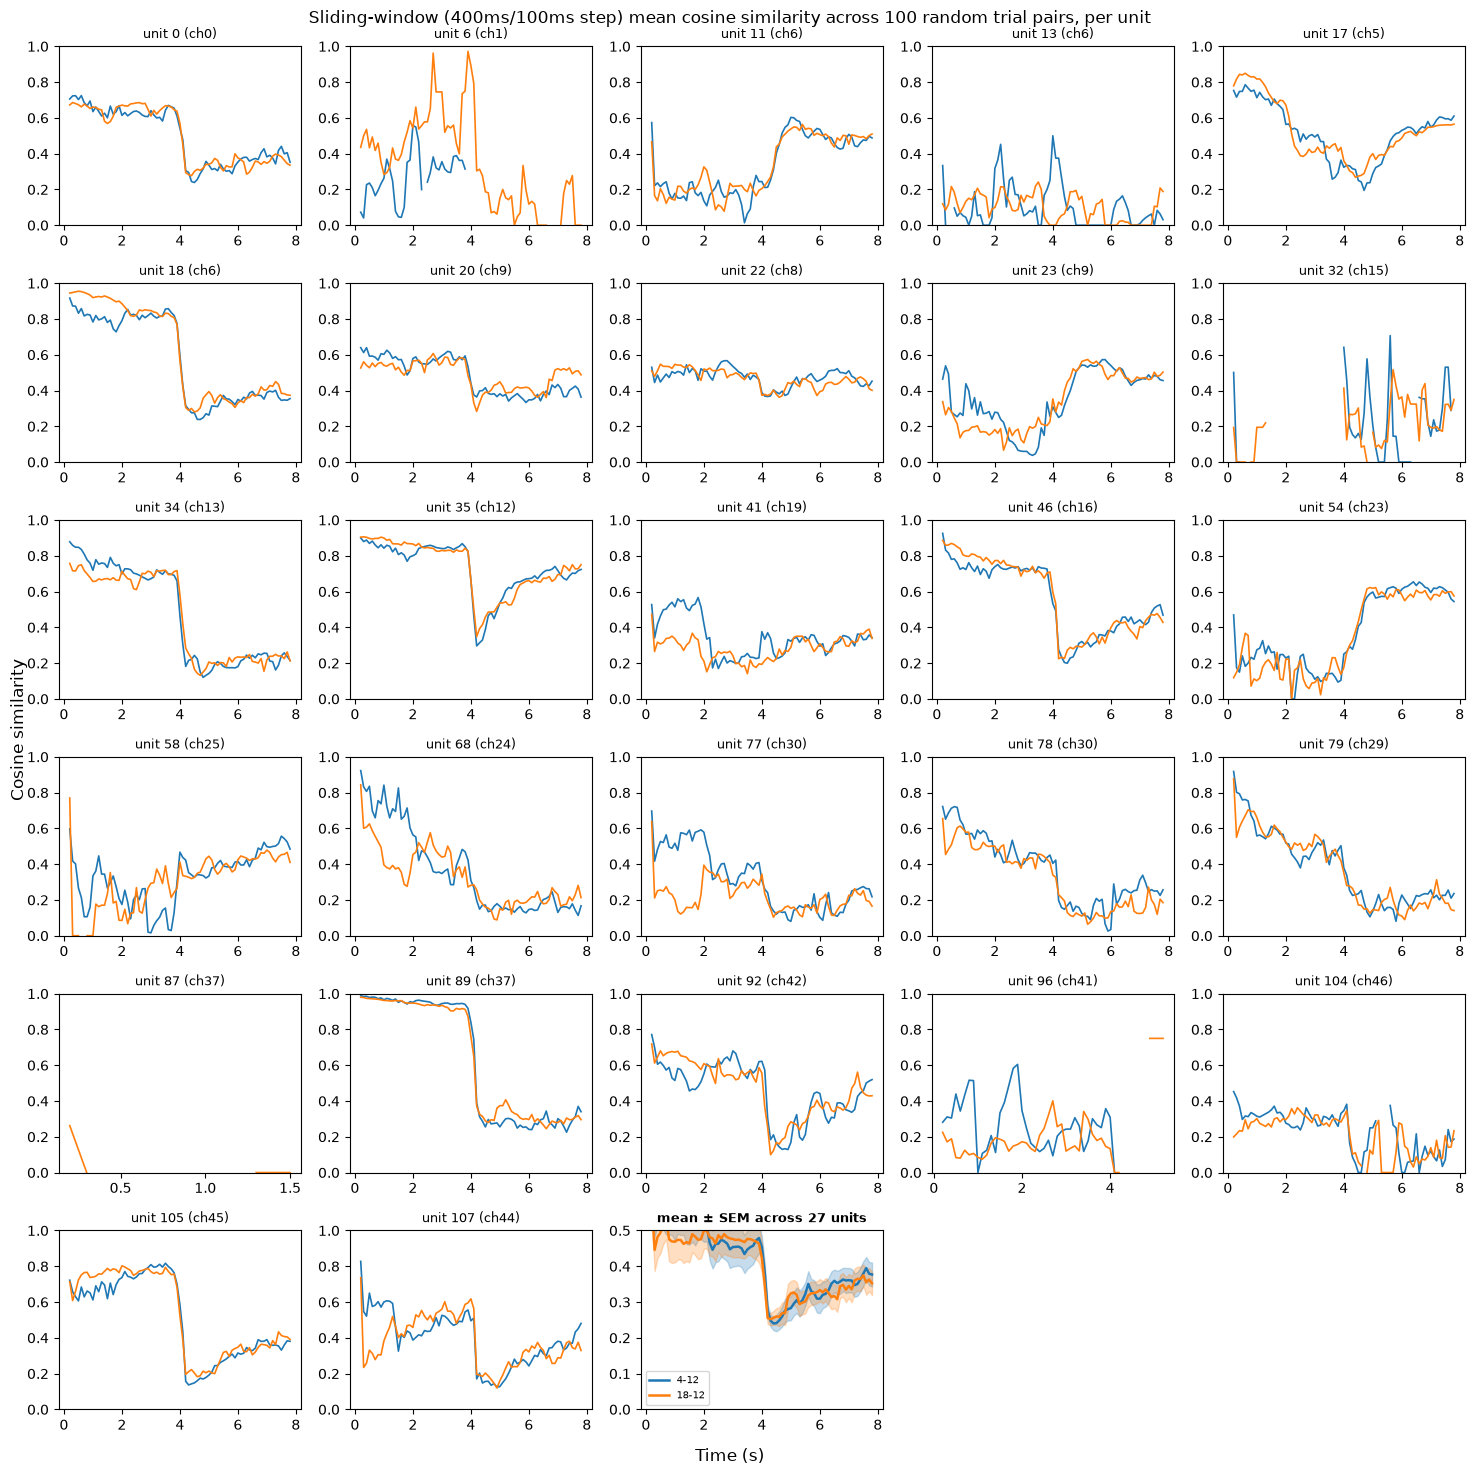

In [11]:
# --- Sliding-window cosine similarity between random trial pairs, per unit ---
# for each neuron: draw 100 random (trial_i, trial_j) pairs from that condition's trials,
# slide a 400ms window (100ms step) over the full FR trace, take the cosine similarity of
# the two trials' FR within each window, then average across the 100 pairs -> one
# similarity-vs-time trace per neuron. Done independently for "4-12" and "18-12".
import itertools

window_size_s = 0.4
step_size_s = 0.1
n_pairs = 100
rng = np.random.default_rng(0)

window_bins = int(round(window_size_s / bin_size_s))
step_bins = int(round(step_size_s / bin_size_s))

def _sliding_cosine_similarity(fr_a, fr_b, window_bins, step_bins):
    n_bins = fr_a.shape[0]
    n_windows = (n_bins - window_bins) // step_bins + 1
    sims = np.full(n_windows, np.nan)
    for w in range(n_windows):
        start = w * step_bins
        a = fr_a[start:start + window_bins]
        b = fr_b[start:start + window_bins]
        norm_a = np.linalg.norm(a)
        norm_b = np.linalg.norm(b)
        if norm_a > 0 and norm_b > 0:
            sims[w] = np.dot(a, b) / (norm_a * norm_b)
    return sims

unit_ids = list(lgn_spike_times.keys())
n_units = len(unit_ids)

similarity_traces = {}  # condition label -> array (n_units, n_windows)
window_times = None

for label, FR in firing_rates.items():
    n_trials, _, n_bins = FR.shape
    n_windows = (n_bins - window_bins) // step_bins + 1
    if window_times is None:
        window_times = (np.arange(n_windows) * step_bins + window_bins / 2) * bin_size_s

    all_pairs = list(itertools.combinations(range(n_trials), 2))
    n_pairs_used = min(n_pairs, len(all_pairs))

    unit_sims = np.zeros((n_units, n_windows))
    for u in range(n_units):
        pair_idx = rng.choice(len(all_pairs), size=n_pairs_used, replace=False)
        pair_sims = np.zeros((n_pairs_used, n_windows))
        for p, idx in enumerate(pair_idx):
            i, j = all_pairs[idx]
            pair_sims[p] = _sliding_cosine_similarity(FR[i, u], FR[j, u], window_bins, step_bins)
        unit_sims[u] = np.nanmean(pair_sims, axis=0)

    similarity_traces[label] = unit_sims
    print(f"{label}: similarity trace shape {unit_sims.shape} (units, windows), from {n_pairs_used} trial pairs/unit")

# --- plot: per-unit subplot grid, 4-12 vs 18-12 overlaid, plus one subplot for the across-unit average ---
colors = {"4-12": "tab:blue", "18-12": "tab:orange"}
ncols = 5
nrows = int(np.ceil((n_units + 1) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
flat_axes = axes.flat

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = flat_axes[i]
    for label in similarity_traces:
        ax.plot(window_times, similarity_traces[label][i], color=colors[label], label=label, linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

avg_ax = flat_axes[n_units]
for label in similarity_traces:
    # per-unit traces can contain NaN (undefined cosine sim when a trial's window has all-zero
    # firing rate); use nan-aware stats so a few silent units/windows don't blank the whole average
    valid_n = np.sum(~np.isnan(similarity_traces[label]), axis=0)
    mean_trace = np.nanmean(similarity_traces[label], axis=0)
    sem_trace = np.nanstd(similarity_traces[label], axis=0, ddof=1) / np.sqrt(valid_n)
    avg_ax.plot(window_times, mean_trace, color=colors[label], label=label, linewidth=1.8)
    avg_ax.fill_between(window_times, mean_trace - sem_trace, mean_trace + sem_trace, color=colors[label], alpha=0.25)
avg_ax.set_ylim(0, 0.5)
avg_ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
avg_ax.set_title(f"mean ± SEM across {n_units} units", fontsize=9, fontweight="bold")
avg_ax.legend(fontsize=7)

for idx in range(n_units + 1, nrows * ncols):
    flat_axes[idx].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("Cosine similarity")
fig.suptitle(f"Sliding-window (400ms/{step_size_s*1000:.0f}ms step) mean cosine similarity across {n_pairs} random trial pairs, per unit")
plt.tight_layout()
plt.show()

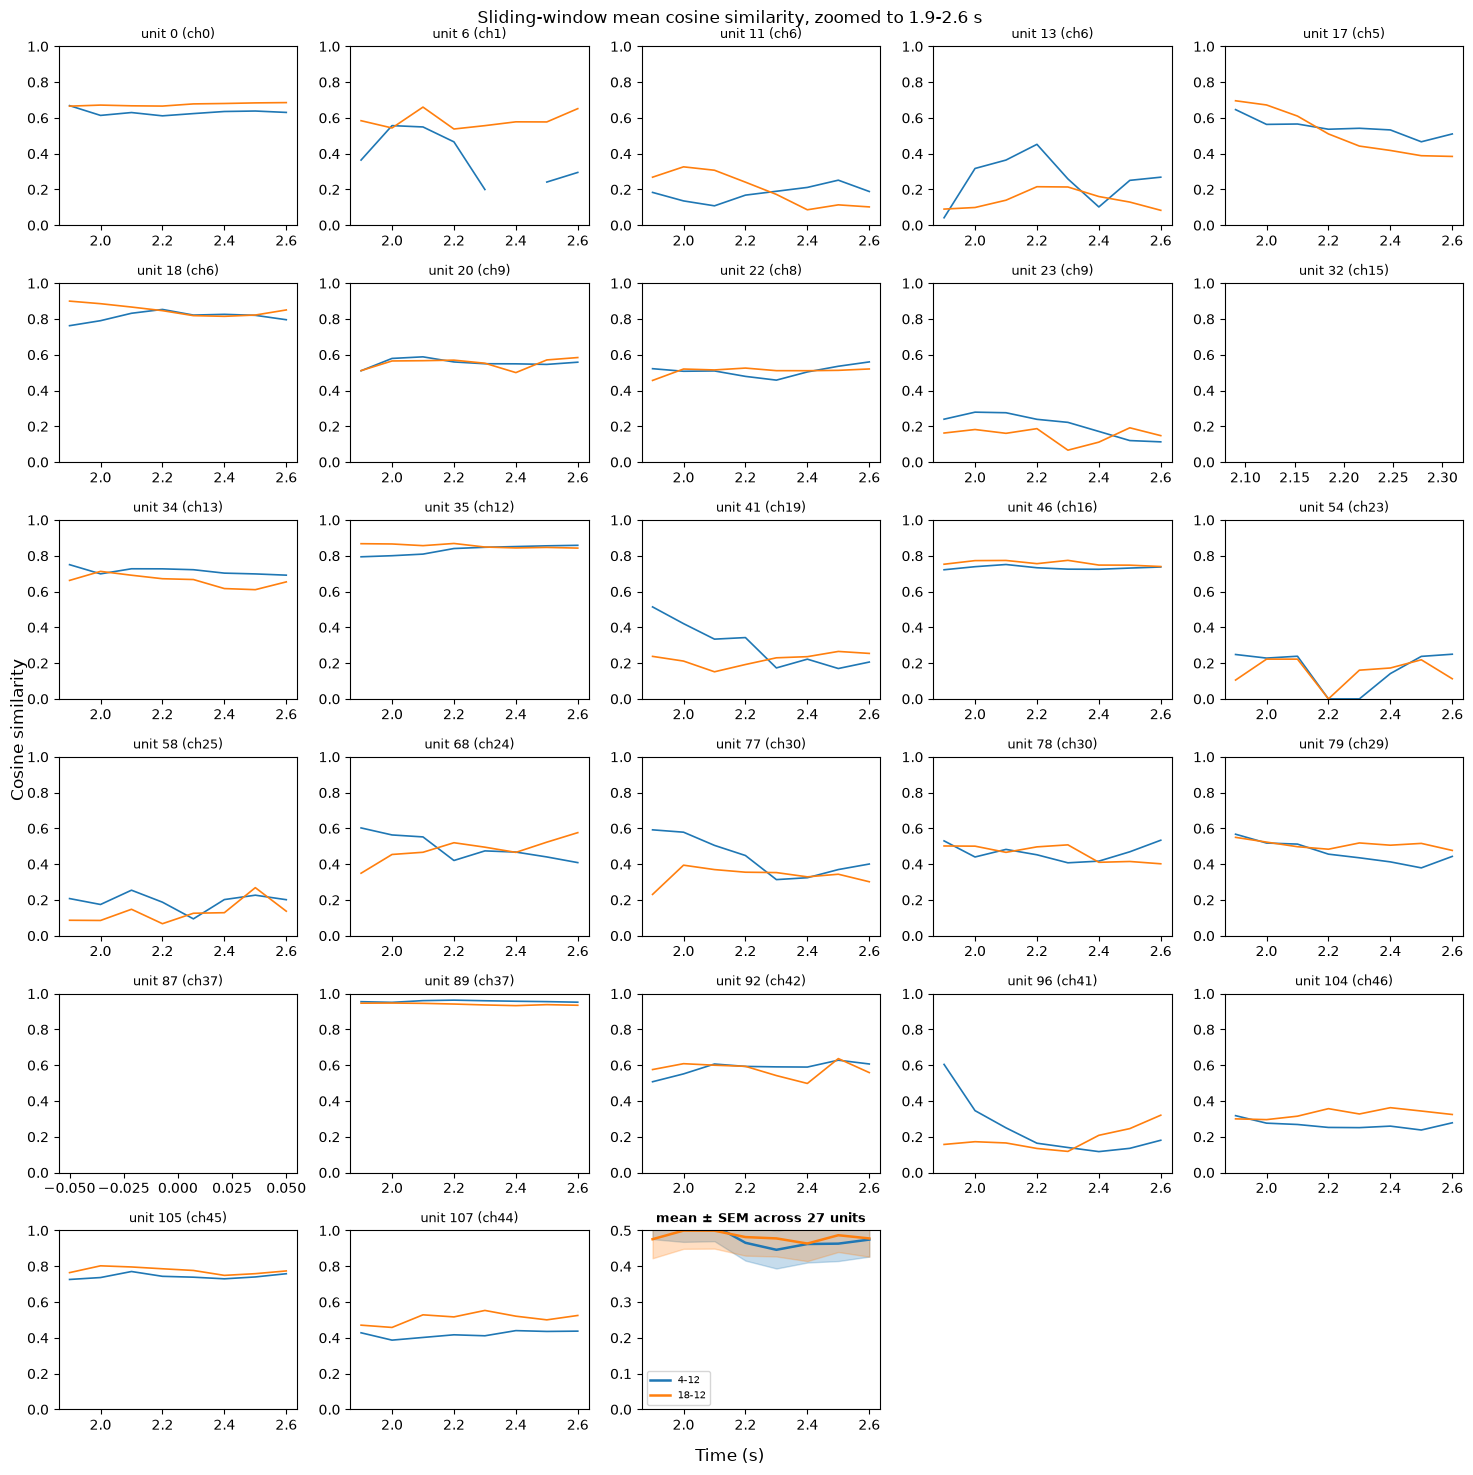

In [12]:
# --- zoomed-in version of the figure above, restricted to 1.9-2.6 s ---
zoom_start_s, zoom_end_s = 1.9, 2.6
zoom_mask = (window_times >= zoom_start_s) & (window_times <= zoom_end_s)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
flat_axes = axes.flat

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = flat_axes[i]
    for label in similarity_traces:
        ax.plot(window_times[zoom_mask], similarity_traces[label][i][zoom_mask], color=colors[label], label=label, linewidth=1.2)
    ax.set_ylim(0, 1)
    ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

avg_ax = flat_axes[n_units]
for label in similarity_traces:
    valid_n = np.sum(~np.isnan(similarity_traces[label]), axis=0)
    mean_trace = np.nanmean(similarity_traces[label], axis=0)
    sem_trace = np.nanstd(similarity_traces[label], axis=0, ddof=1) / np.sqrt(valid_n)
    avg_ax.plot(window_times[zoom_mask], mean_trace[zoom_mask], color=colors[label], label=label, linewidth=1.8)
    avg_ax.fill_between(window_times[zoom_mask], (mean_trace - sem_trace)[zoom_mask], (mean_trace + sem_trace)[zoom_mask], color=colors[label], alpha=0.25)
avg_ax.set_ylim(0, 0.5)
avg_ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
avg_ax.set_title(f"mean ± SEM across {n_units} units", fontsize=9, fontweight="bold")
avg_ax.legend(fontsize=7)

for idx in range(n_units + 1, nrows * ncols):
    flat_axes[idx].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("Cosine similarity")
fig.suptitle(f"Sliding-window mean cosine similarity, zoomed to {zoom_start_s}-{zoom_end_s} s")
plt.tight_layout()
plt.show()

4-12: distance trace shape (27, 77) (units, windows), from 100 trial pairs/unit
18-12: distance trace shape (27, 77) (units, windows), from 100 trial pairs/unit


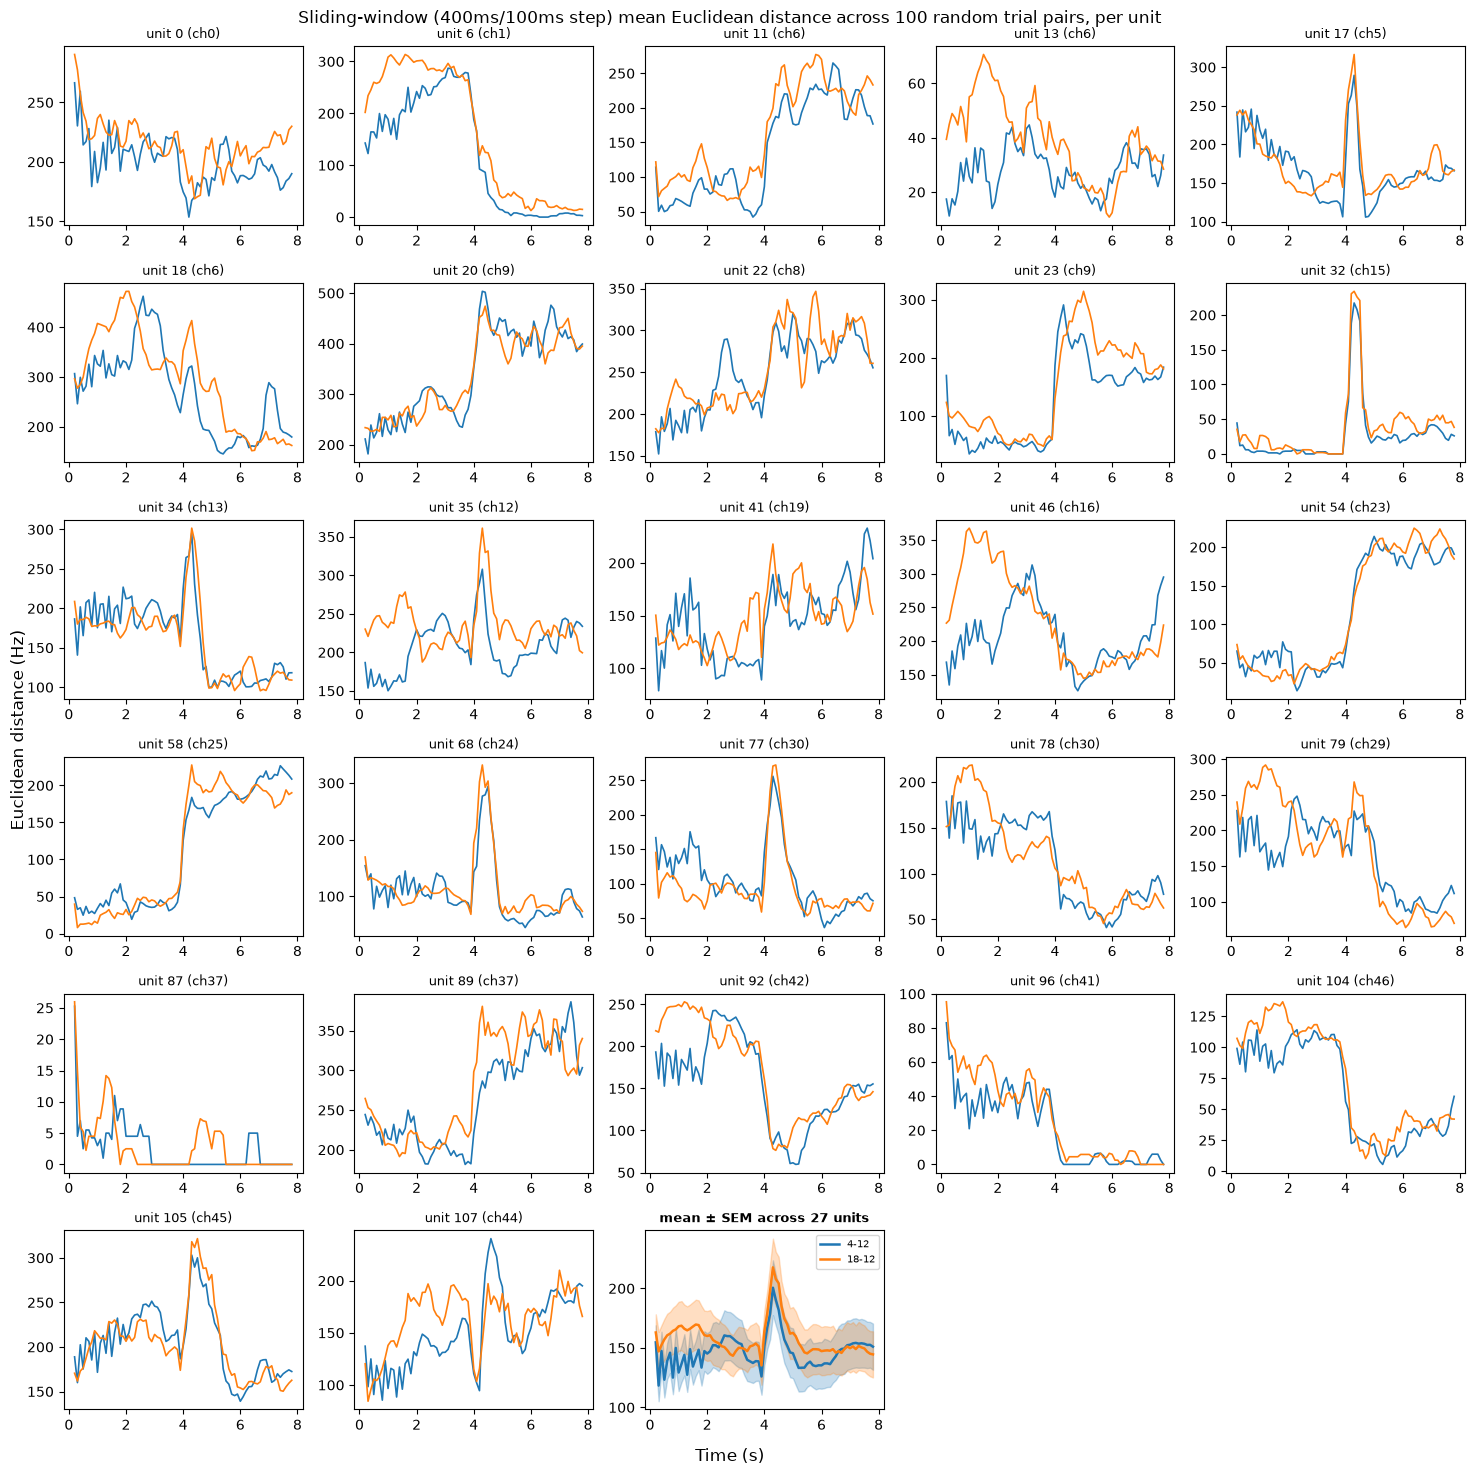

In [13]:
# --- Sliding-window Euclidean distance between random trial pairs, per unit ---
# same procedure as the cosine-similarity analysis above, but using Euclidean distance
# between the two trials' FR within each window instead of cosine similarity.
rng = np.random.default_rng(0)  # same seed -> same random trial pairs as the cosine-similarity cell

def _sliding_euclidean_distance(fr_a, fr_b, window_bins, step_bins):
    n_bins = fr_a.shape[0]
    n_windows = (n_bins - window_bins) // step_bins + 1
    dists = np.full(n_windows, np.nan)
    for w in range(n_windows):
        start = w * step_bins
        a = fr_a[start:start + window_bins]
        b = fr_b[start:start + window_bins]
        dists[w] = np.linalg.norm(a - b)
    return dists

distance_traces = {}  # condition label -> array (n_units, n_windows)

for label, FR in firing_rates.items():
    n_trials, _, n_bins = FR.shape
    n_windows = (n_bins - window_bins) // step_bins + 1

    all_pairs = list(itertools.combinations(range(n_trials), 2))
    n_pairs_used = min(n_pairs, len(all_pairs))

    unit_dists = np.zeros((n_units, n_windows))
    for u in range(n_units):
        pair_idx = rng.choice(len(all_pairs), size=n_pairs_used, replace=False)
        pair_dists = np.zeros((n_pairs_used, n_windows))
        for p, idx in enumerate(pair_idx):
            i, j = all_pairs[idx]
            pair_dists[p] = _sliding_euclidean_distance(FR[i, u], FR[j, u], window_bins, step_bins)
        unit_dists[u] = np.nanmean(pair_dists, axis=0)

    distance_traces[label] = unit_dists
    print(f"{label}: distance trace shape {unit_dists.shape} (units, windows), from {n_pairs_used} trial pairs/unit")

# --- plot: per-unit subplot grid, 4-12 vs 18-12 overlaid, plus one subplot for the across-unit average ---
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
flat_axes = axes.flat

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = flat_axes[i]
    for label in distance_traces:
        ax.plot(window_times, distance_traces[label][i], color=colors[label], label=label, linewidth=1.2)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

avg_ax = flat_axes[n_units]
for label in distance_traces:
    # nan-aware stats: undefined windows (e.g. all-zero FR on both trials) shouldn't blank the average
    valid_n = np.sum(~np.isnan(distance_traces[label]), axis=0)
    mean_trace = np.nanmean(distance_traces[label], axis=0)
    sem_trace = np.nanstd(distance_traces[label], axis=0, ddof=1) / np.sqrt(valid_n)
    avg_ax.plot(window_times, mean_trace, color=colors[label], label=label, linewidth=1.8)
    avg_ax.fill_between(window_times, mean_trace - sem_trace, mean_trace + sem_trace, color=colors[label], alpha=0.25)
avg_ax.set_title(f"mean ± SEM across {n_units} units", fontsize=9, fontweight="bold")
avg_ax.legend(fontsize=7)

for idx in range(n_units + 1, nrows * ncols):
    flat_axes[idx].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("Euclidean distance (Hz)")
fig.suptitle(f"Sliding-window (400ms/{step_size_s*1000:.0f}ms step) mean Euclidean distance across {n_pairs} random trial pairs, per unit")
plt.tight_layout()
plt.show()

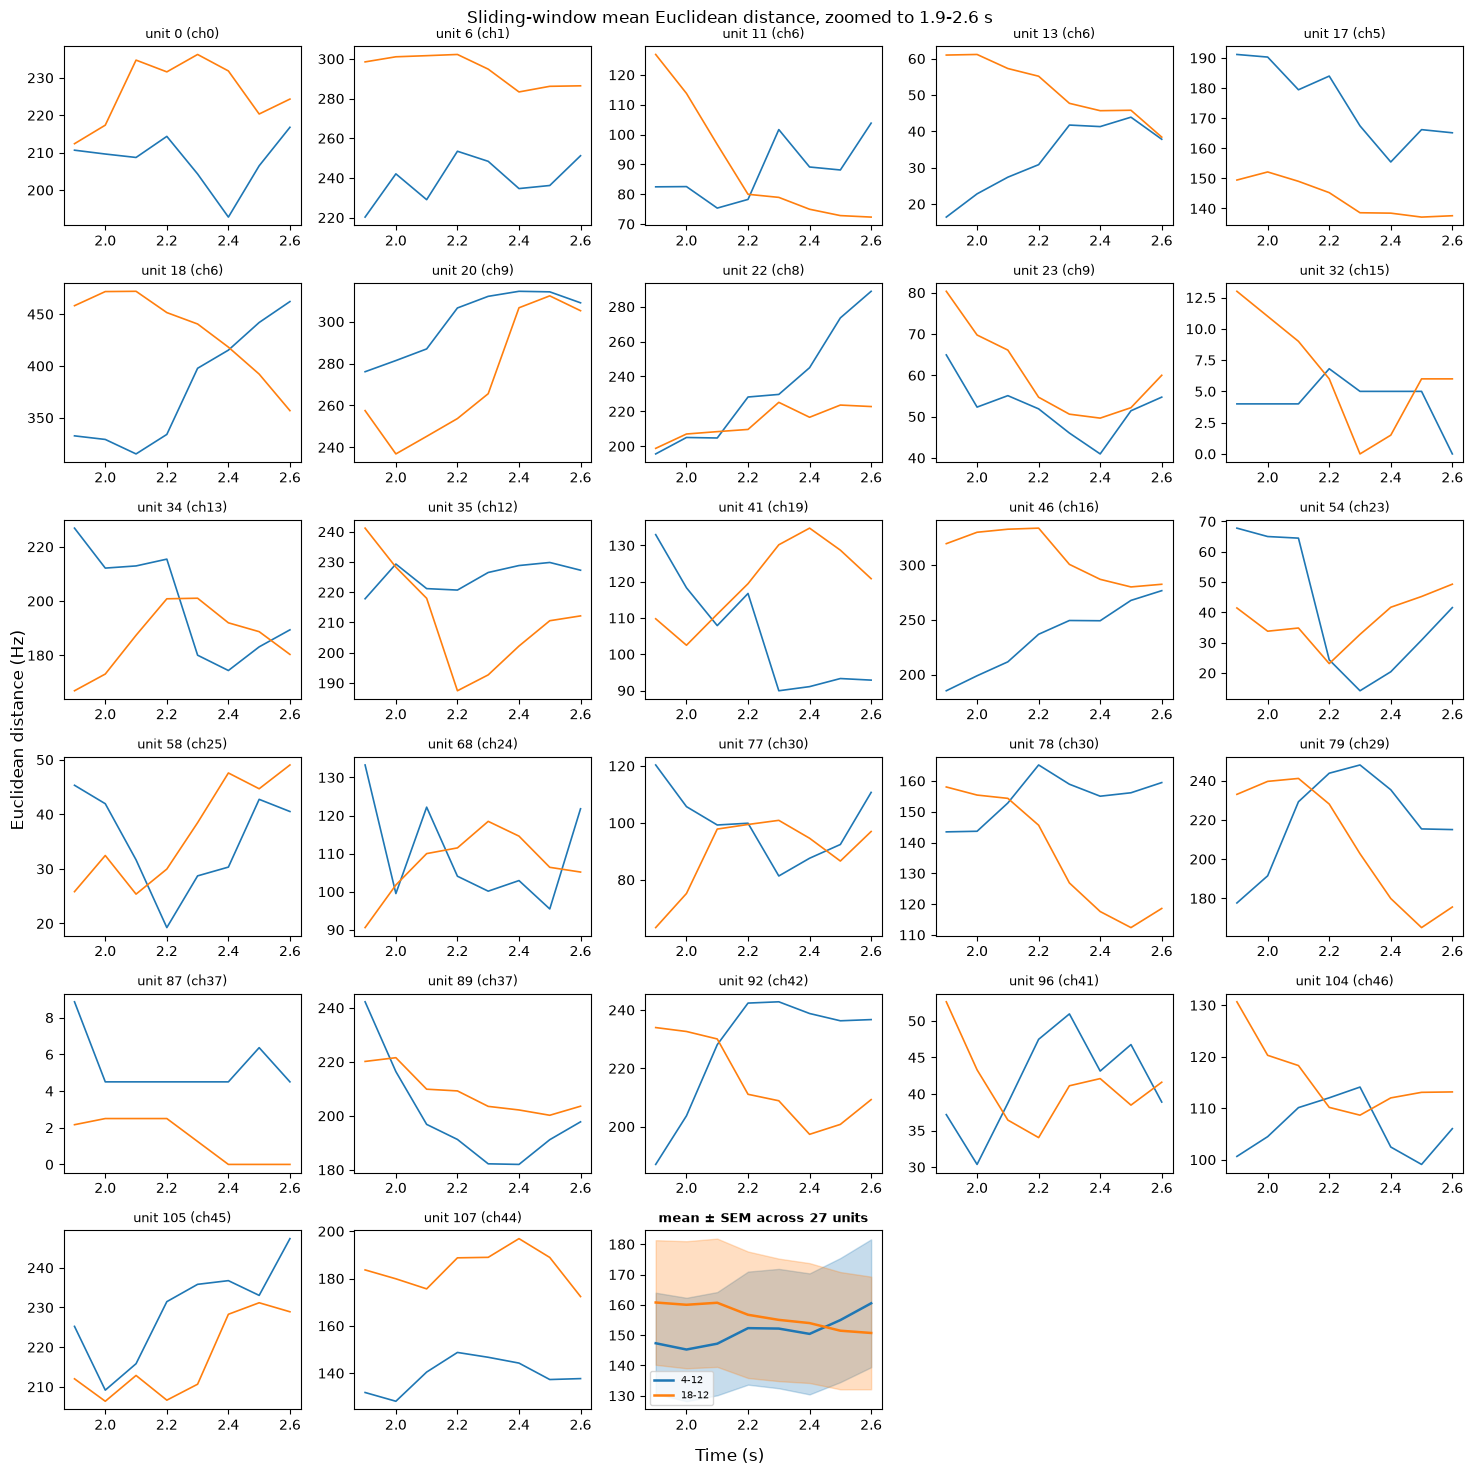

In [14]:
# --- zoomed-in version of the Euclidean distance figure above, restricted to 1.9-2.6 s ---
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
flat_axes = axes.flat

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = flat_axes[i]
    for label in distance_traces:
        ax.plot(window_times[zoom_mask], distance_traces[label][i][zoom_mask], color=colors[label], label=label, linewidth=1.2)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

avg_ax = flat_axes[n_units]
for label in distance_traces:
    valid_n = np.sum(~np.isnan(distance_traces[label]), axis=0)
    mean_trace = np.nanmean(distance_traces[label], axis=0)
    sem_trace = np.nanstd(distance_traces[label], axis=0, ddof=1) / np.sqrt(valid_n)
    avg_ax.plot(window_times[zoom_mask], mean_trace[zoom_mask], color=colors[label], label=label, linewidth=1.8)
    avg_ax.fill_between(window_times[zoom_mask], (mean_trace - sem_trace)[zoom_mask], (mean_trace + sem_trace)[zoom_mask], color=colors[label], alpha=0.25)
avg_ax.set_title(f"mean ± SEM across {n_units} units", fontsize=9, fontweight="bold")
avg_ax.legend(fontsize=7)

for idx in range(n_units + 1, nrows * ncols):
    flat_axes[idx].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("Euclidean distance (Hz)")
fig.suptitle(f"Sliding-window mean Euclidean distance, zoomed to {zoom_start_s}-{zoom_end_s} s")
plt.tight_layout()
plt.show()

In [ ]:
# --- Cycle-by-Cycle Harmonic Fitting: phase shift of each PSTH cycle's peak from the
# cognate 12 Hz stimulus sinusoid's peak, per trial and per neuron, restricted to 2-4 s ---
# assumes the shared 12 Hz carrier is itself a pure cosine that peaks exactly at each
# trial's (chirp-onset-refined) t=0, so cycle k's cognate stimulus peak sits at
# t = k * cycle_period_s; fitting one sinusoid per cycle window to the PSTH and reading
# off its peak time relative to that cognate peak gives the cycle-by-cycle phase shift.
carrier_freq = 12.0  # Hz - the carrier shared by both "4-12" and "18-12" conditions
cycle_period_s = 1.0 / carrier_freq
omega = 2 * np.pi * carrier_freq

analysis_start_s, analysis_end_s = 2.0, 4.0
start_cycle = int(round(analysis_start_s / cycle_period_s))
end_cycle = int(round(analysis_end_s / cycle_period_s))  # (4-2)s / (1/12s) = 24 whole cycles

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
cycle_times = (np.arange(start_cycle, end_cycle) + 0.5) * cycle_period_s  # cycle-center time, for plotting
n_cycles = len(cycle_times)

def _wrap_to_half_period(x, period):
    return ((x + period / 2) % period) - period / 2

phase_shift_ms = {}     # condition label -> array (n_trials, n_units, n_cycles), ms
cycle_amplitude = {}    # condition label -> array (n_trials, n_units, n_cycles), fitted sinusoid amplitude (Hz)

for label, FR in firing_rates.items():
    n_trials_c, n_units_c, _ = FR.shape
    shifts = np.full((n_trials_c, n_units_c, n_cycles), np.nan)
    amps = np.full((n_trials_c, n_units_c, n_cycles), np.nan)

    for ci, k in enumerate(range(start_cycle, end_cycle)):
        cycle_mask = (bin_centers >= k * cycle_period_s) & (bin_centers < (k + 1) * cycle_period_s)
        t_cycle = bin_centers[cycle_mask]
        X = np.column_stack([np.cos(omega * t_cycle), np.sin(omega * t_cycle), np.ones_like(t_cycle)])

        Y = FR[:, :, cycle_mask].reshape(n_trials_c * n_units_c, -1).T  # (n_time_points, n_trials*n_units)
        coeffs, *_ = np.linalg.lstsq(X, Y, rcond=None)  # (3, n_trials*n_units)
        a, b, c = coeffs
        amplitude = np.hypot(a, b)
        phase = np.arctan2(b, a)  # FR ~= amplitude*cos(omega*t - phase) + c -> peaks where omega*t == phase (mod 2 pi)

        shift_s = _wrap_to_half_period(phase / omega, cycle_period_s)
        shifts[:, :, ci] = shift_s.reshape(n_trials_c, n_units_c) * 1000.0
        amps[:, :, ci] = amplitude.reshape(n_trials_c, n_units_c)

    phase_shift_ms[label] = shifts
    cycle_amplitude[label] = amps
    print(f"{label}: phase-shift array shape {shifts.shape} (trials, units, cycles), "
          f"cycles {start_cycle}-{end_cycle - 1} ({analysis_start_s}-{analysis_end_s} s); "
          f"mean |shift| = {np.nanmean(np.abs(shifts)):.2f} ms")

# --- plot: per-unit subplot grid, trial-mean cycle-by-cycle phase shift (4-12 vs 18-12),
# plus one subplot for the across-unit average. phase shift is a wrapped angle, so trial-
# and unit-averaging use a circular mean (SEM stays in linear ms, an approximation valid
# as long as shifts don't cluster near the +/- half-period wrap boundary). ---
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.5 * nrows), squeeze=False)
flat_axes = axes.flat

for i in range(n_units):
    unit_id = unit_ids[i]
    ax = flat_axes[i]
    for label in phase_shift_ms:
        angle = phase_shift_ms[label][:, i, :] / cycle_period_s / 1000.0 * 2 * np.pi
        mean_angle = np.angle(np.nanmean(np.exp(1j * angle), axis=0))
        mean_shift_ms = mean_angle / (2 * np.pi) * cycle_period_s * 1000.0
        ax.plot(cycle_times, mean_shift_ms, color=colors[label], label=label, linewidth=1.2)
    ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
    ax.set_title(f"unit {unit_id} (ch{unit_data[unit_id]['channel']})", fontsize=9)

avg_ax = flat_axes[n_units]
for label in phase_shift_ms:
    n_trials_this = phase_shift_ms[label].shape[0]
    angle = phase_shift_ms[label] / cycle_period_s / 1000.0 * 2 * np.pi  # (trials, units, cycles)
    mean_angle = np.angle(np.nanmean(np.exp(1j * angle), axis=(0, 1)))
    mean_shift_ms = mean_angle / (2 * np.pi) * cycle_period_s * 1000.0
    sem_shift_ms = np.nanstd(phase_shift_ms[label], axis=(0, 1), ddof=1) / np.sqrt(n_trials_this * n_units)
    avg_ax.plot(cycle_times, mean_shift_ms, color=colors[label], label=label, linewidth=1.8)
    avg_ax.fill_between(cycle_times, mean_shift_ms - sem_shift_ms, mean_shift_ms + sem_shift_ms, color=colors[label], alpha=0.25)
avg_ax.axhline(0, color="#cccccc", linewidth=0.8, zorder=0)
avg_ax.set_title(f"mean ± SEM across {n_units} units", fontsize=9, fontweight="bold")
avg_ax.legend(fontsize=7)

for idx in range(n_units + 1, nrows * ncols):
    flat_axes[idx].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("PSTH-peak shift from cognate stimulus peak (ms)")
fig.suptitle(f"Cycle-by-cycle harmonic-fit phase shift at {carrier_freq:.0f} Hz, {analysis_start_s}-{analysis_end_s} s, trial-mean per unit")
plt.tight_layout()
plt.show()